In [ ]:
from utils import Utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# df = Utils.create_df("./d
# ata/anonymized_data/")
# pd.DataFrame(df).reset_index().to_csv("data/created_df.csv", index=False)
df = pd.read_csv("data/created_df.csv")
df["date"] = pd.to_datetime(df["date"])
n = 25
df = Utils.get_first_n_assets(df, n)
features = Utils.add_signals(Utils.get_features(df).dropna())

In [3]:
features.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'tic', 'log-ret',
       'rsi_6', 'rsi', 'cci_6', 'cci', 'dx', 'adx', 'adxr', 'close_5_sma',
       'close_20_ema', 'close_5_ema', 'cci_5', 'pdi', 'ndi', 'stochrsi_3',
       'macd', 'macds', 'macdh', 'tema', 'pvo', 'pvos', 'pvoh', 'volatility',
       'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal'],
      dtype='str')

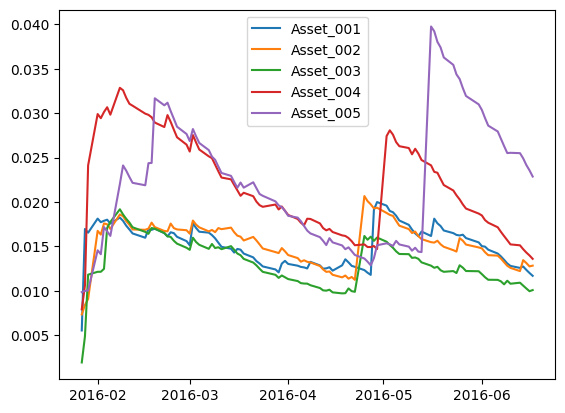

In [60]:
for i in range(5):
    one = features[features["tic"] == features["tic"].iloc[i]]
    plt.plot(one['date'][:100], one['volatility'][:100], label = one['tic'].iloc[0])
plt.legend()
plt.show()

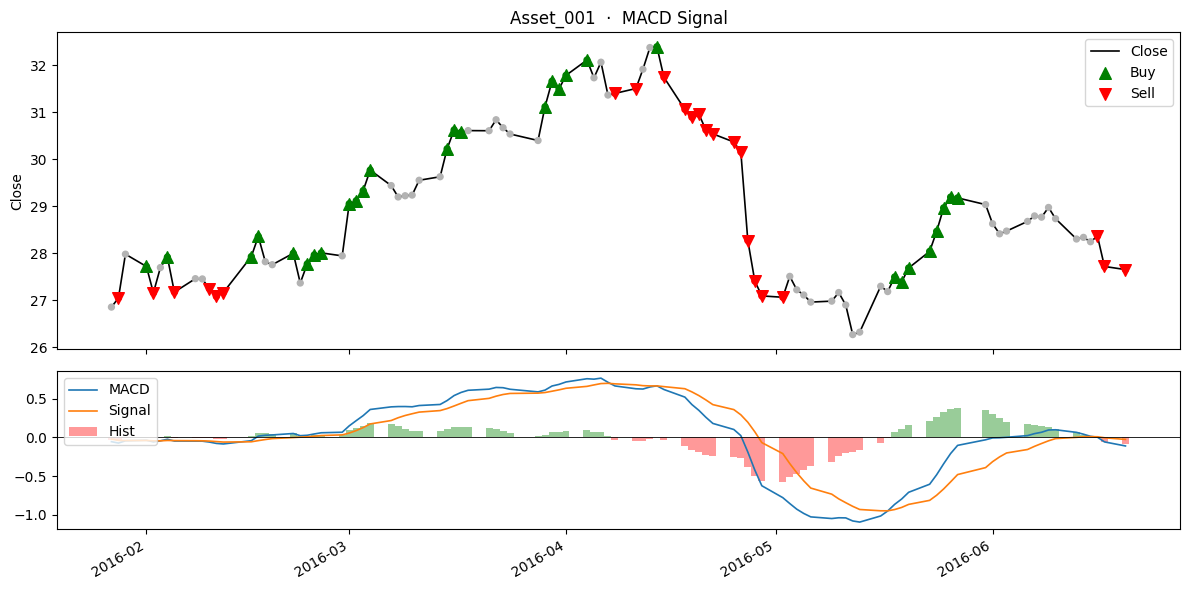

In [5]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
signal = one[["date", "macd_signal", "rsi_signal", "adx_signal", "cci_signal"]].copy()
sig = one['macd_signal']
label = "MACD Signal"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['macd_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_m) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates, close, c=["g" if v == 1 else "r" if v == -1 else "0.7" for v in s], s=18, zorder=3)
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=4, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=4, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}"); ax.set_ylabel("Close"); ax.legend()
ax_m.plot(dates, px["macd"], color="C0", lw=1.2, label="MACD"); ax_m.plot(dates, px["macds"], color="C1", lw=1.2, label="Signal")
ax_m.bar(dates, px["macdh"], color=["g" if v >= 0 else "r" for v in px["macdh"]], width=1.0, alpha=0.4, label="Hist")
ax_m.axhline(0, color="k", lw=0.6); ax_m.legend(loc="upper left")
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

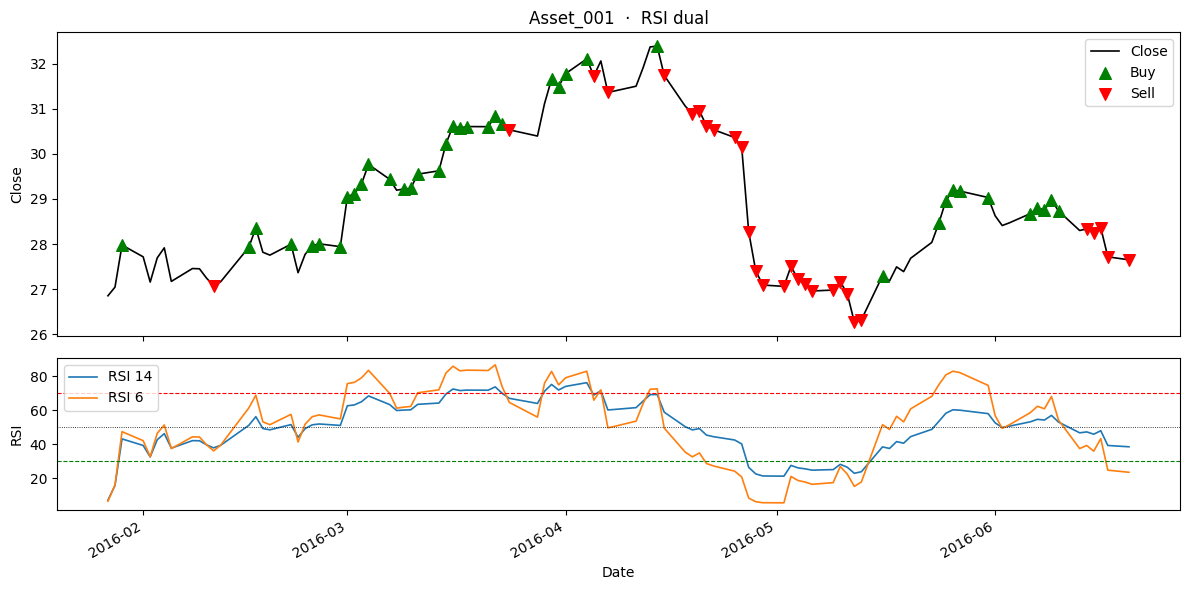

In [6]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
rsi_sig = one['rsi_signal']
# macd_cross, macd_zero = Utils.get_macd_signal(one["macd"], one["macds"], one["macdh"])

# pick the series to draw: rsi_sig, macd_cross, or macd_zero
sig = rsi_sig
label = "RSI dual"

window = slice(None, 100)  # first 100 bars; use slice(None) for all
px = one.loc[window]
s = px['rsi_signal']
dates = pd.to_datetime(px["date"])
close = px["close"]

buy = s == 1
sell = s == -1

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax.plot(dates, close, color="black", lw=1.2, label="Close")
ax.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax.set_title(f"{one['tic'].iloc[0]}  ·  {label}")
ax.set_ylabel("Close")
ax.legend()

ax_r.plot(dates, px["rsi"], color="C0", lw=1.2, label="RSI 14")
ax_r.plot(dates, px["rsi_6"], color="C1", lw=1.2, label="RSI 6")
ax_r.axhline(70, color="r", ls="--", lw=0.8)
ax_r.axhline(30, color="g", ls="--", lw=0.8)
ax_r.axhline(50, color="k", ls=":", lw=0.6)
ax_r.set_ylabel("RSI")
ax_r.set_xlabel("Date")
ax_r.legend(loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

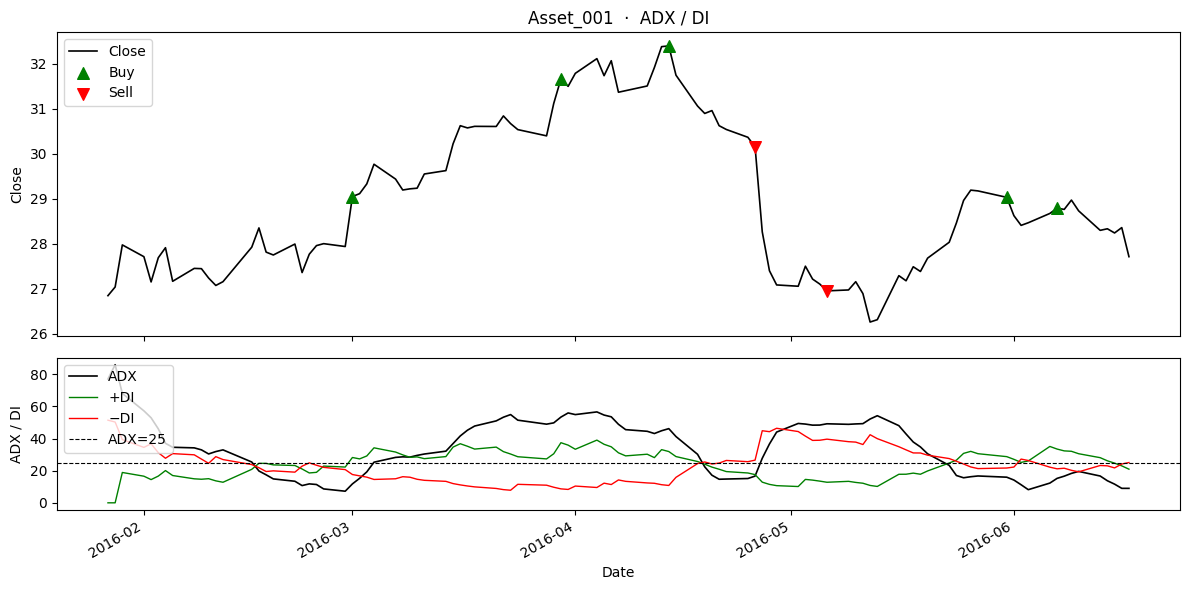

In [7]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
adx_sig = one["adx_signal"]
label = "ADX Signal"

window = slice(None, 100)
px = one.iloc[window]
s = px["adx_signal"]
changed = s != s.shift()
buy = (s == 1) & changed
sell = (s == -1) & changed
dates = pd.to_datetime(px["date"])
close = px["close"]

fig, (ax_px, ax_adx) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax_px.plot(dates, close, color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], close[buy], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], close[sell], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  ADX / DI")
ax_px.legend(loc="upper left")

ax_adx.plot(dates, px["adx"], color="black", lw=1.2, label="ADX")
ax_adx.plot(dates, px["pdi"], color="green", lw=1.0, label="+DI")
ax_adx.plot(dates, px["ndi"], color="red", lw=1.0, label="−DI")
ax_adx.axhline(25, color="k", ls="--", lw=0.8, label="ADX=25")
ax_adx.set_ylabel("ADX / DI")
ax_adx.set_xlabel("Date")
ax_adx.legend(loc="upper left")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

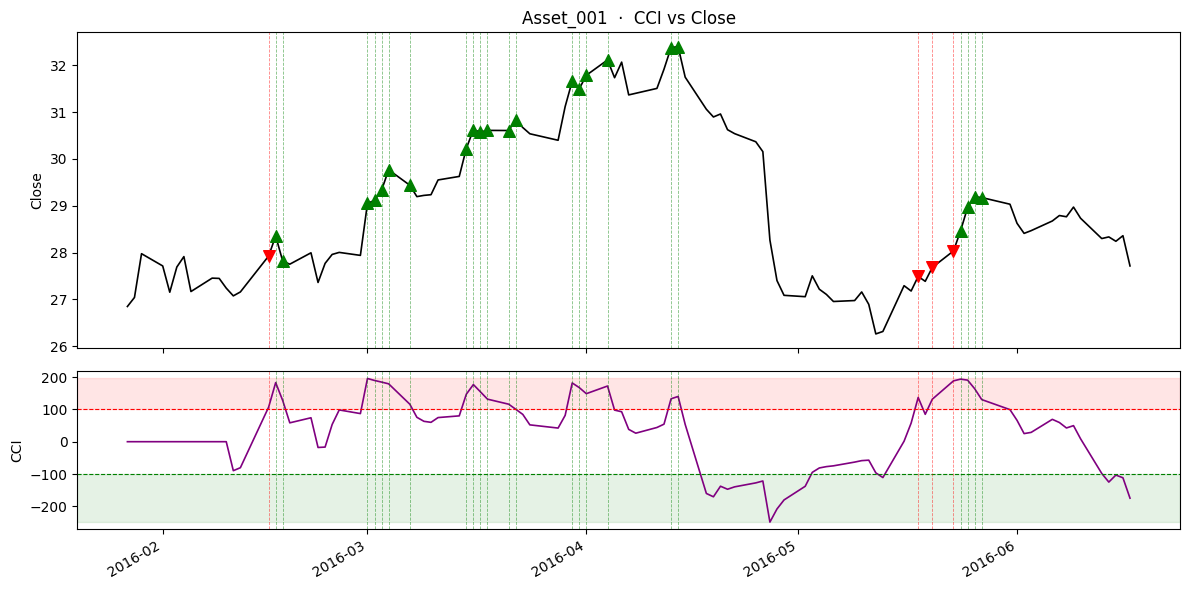

In [8]:
one = features[features["tic"] == features["tic"].iloc[0]].reset_index(drop=True).copy()
window = slice(None, 100)
px = one.iloc[window]
dates = pd.to_datetime(px["date"])
s = px["cci_signal"]
buy, sell = s == 1, s == -1
fig, (ax_px, ax_cci) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
ax_px.plot(dates, px["close"], color="black", lw=1.2, label="Close")
ax_px.scatter(dates[buy], px.loc[buy, "close"], marker="^", s=70, color="green", zorder=3, label="Buy")
ax_px.scatter(dates[sell], px.loc[sell, "close"], marker="v", s=70, color="red", zorder=3, label="Sell")
ax_px.set_ylabel("Close")
ax_px.set_title(f"{one['tic'].iloc[0]}  ·  CCI vs Close")
ax_cci.plot(dates, px["cci"], color="purple", lw=1.2, label="CCI")
ax_cci.axhline(100, color="r", ls="--", lw=0.8)
ax_cci.axhline(-100, color="g", ls="--", lw=0.8)
ax_cci.axhspan(100, px["cci"].max(), color="r", alpha=0.1)
ax_cci.axhspan(px["cci"].min(), -100, color="g", alpha=0.1)
ax_cci.set_ylabel("CCI")
[ax.axvline(d, color="g" if b else "r", ls="--", lw=0.6, alpha=0.5) for ax in (ax_px, ax_cci) for d, b, se in zip(dates, buy, sell) if b or se]
fig.autofmt_xdate(); fig.tight_layout(); plt.show()


In [9]:
for col in ["macd_signal", "rsi_signal", "adx_signal", "cci_signal"]:
    features[col + "_held"] = features.groupby("tic", sort=False)[col].transform(
        Utils.hold_until_opposite
    )

In [10]:
features.head()

,date,open,high,low,close,volume,tic,log-ret,rsi_6,rsi,...,pvoh,volatility,macd_signal,rsi_signal,adx_signal,cci_signal,macd_signal_held,rsi_signal_held,adx_signal_held,cci_signal_held
2,2016-01-27,27.603374,27.772948,26.827351,26.850345,642328247.0,Asset_001,-0.067965,6.520784,7.212268,...,1.374716,0.005531,0,0,0,0,0,0,0,0
2,2016-01-27,63.138625,63.369282,61.936796,62.179591,27033807.0,Asset_002,-0.018377,24.999527,27.082835,...,0.272430,0.007337,0,0,0,0,0,0,0,0
2,2016-01-27,36.431252,36.664288,35.447055,35.732921,57710800.0,Asset_003,-0.018472,8.045363,8.883155,...,0.717573,0.001925,0,0,0,0,0,0,0,0
2,2016-01-27,34.438470,34.518561,33.110678,33.372117,74770606.0,Asset_004,-0.030223,18.015263,19.669184,...,0.444845,0.007912,0,0,0,0,0,0,0,0
2,2016-01-27,0.915523,0.918398,0.888690,0.905939,177477475.0,Asset_005,-0.011918,40.696758,43.332401,...,-0.142705,0.009852,0,0,0,0,0,0,0,0


### IC IR Test for the signals

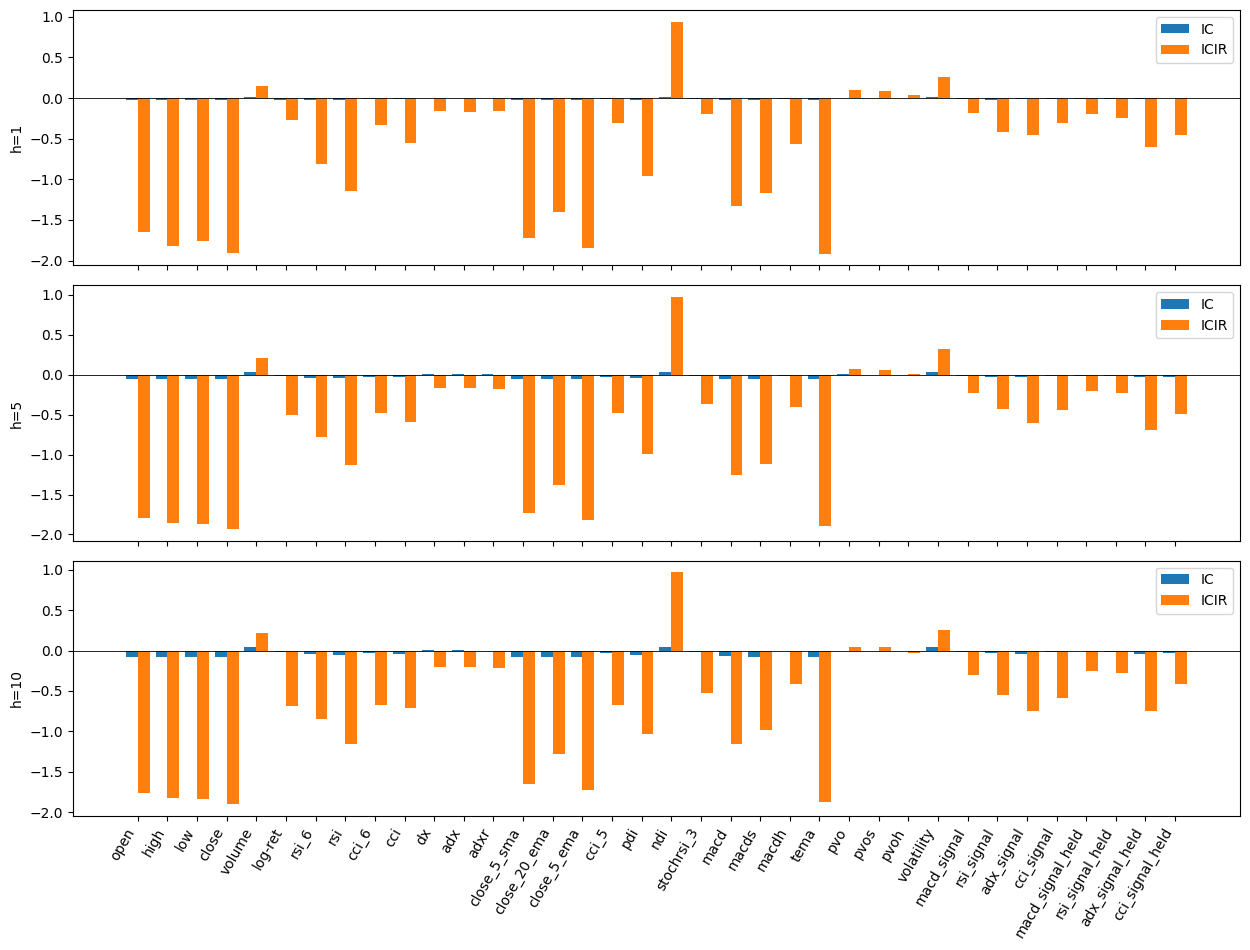

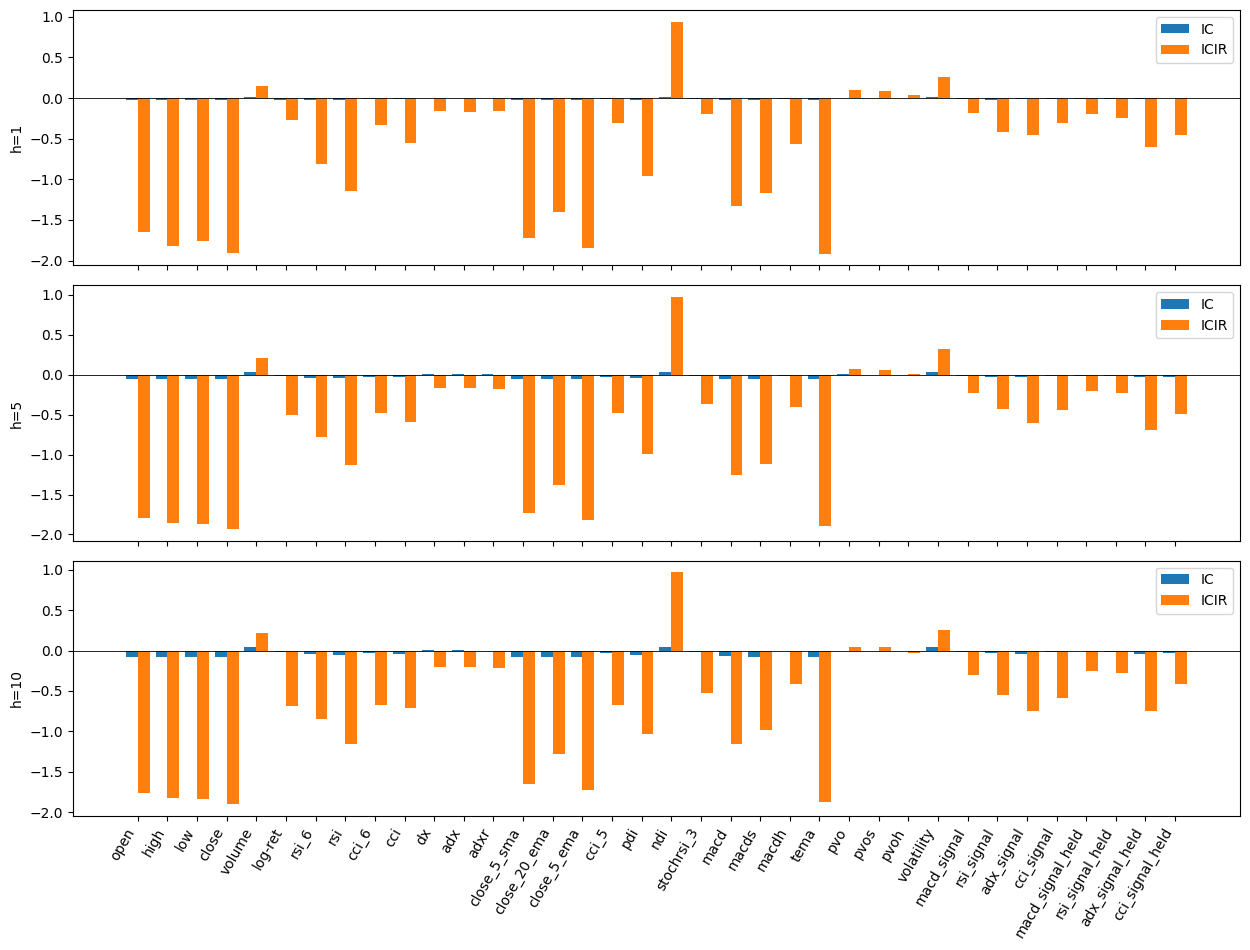

In [11]:
icir_df = Utils.get_ic(features)

def plot_icir(icir_df, metrics=("IC", "ICIR")):
    """One figure per horizon; grouped bars for each metric."""
    frame = icir_df.dropna(subset=["h"]).copy()
    horizons = sorted(frame["h"].unique())
    fig, axes = plt.subplots(
        len(horizons), 1,
        figsize=(max(10, 0.35 * frame["signal"].nunique()), 3.2 * len(horizons)),
        sharex=True,
    )
    if len(horizons) == 1:
        axes = [axes]
    x = np.arange(frame["signal"].nunique())
    names = list(frame.groupby("signal", sort=False).groups)
    width = 0.8 / len(metrics)
    for ax, h in zip(axes, horizons):
        sub = frame[frame["h"] == h].set_index("signal").reindex(names)
        for i, metric in enumerate(metrics):
            ax.bar(
                x + (i - (len(metrics) - 1) / 2) * width,
                sub[metric],
                width,
                label=metric,
            )
        ax.axhline(0, color="k", lw=0.6)
        ax.set_ylabel(f"h={int(h)}")
        ax.legend(loc="upper right")
    axes[-1].set_xticks(x, names, rotation=60, ha="right")
    fig.tight_layout()
    plt.show()
    return fig
plot_icir(icir_df)

In [12]:
features['macd']

2       -0.054038
2       -0.022575
2       -0.018659
2       -0.024035
2       -0.000081
          ...    
2510     5.544672
2510     1.619391
2510    -1.688088
2510    19.907050
2510    -0.555952
Name: macd, Length: 62725, dtype: float64

In [13]:
def standardize(x):
    return (x - x.mean()) / x.std()

In [14]:
features['macd_stad'] = features.groupby('tic')['macd'].transform(standardize)
features['macds_stad'] = features.groupby('tic')['macds'].transform(standardize)

<Axes: >

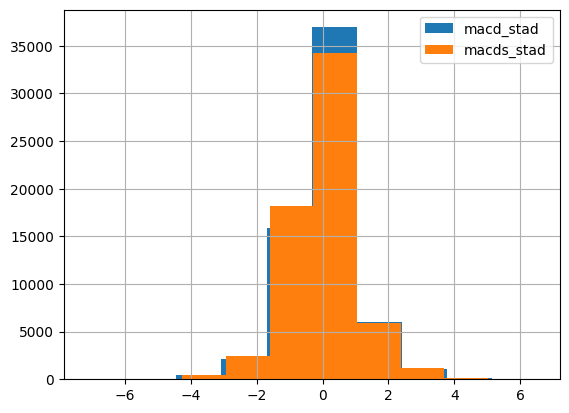

In [15]:
features['macd_stad'].hist(legend = True)
features['macds_stad'].hist(legend = True)

In [16]:
print(features['macd_stad'].describe())
print(features['macds_stad'].describe())

count    62725.000000
mean         0.000000
std          0.999809
min         -7.177405
25%         -0.425208
50%         -0.072189
75%          0.464671
max          6.512787
Name: macd_stad, dtype: float64
count    62725.000000
mean         0.000000
std          0.999809
min         -6.908119
25%         -0.432968
50%         -0.077562
75%          0.464684
max          6.347705
Name: macds_stad, dtype: float64


In [32]:
features['tema_stad'] = features.groupby('tic')['tema'].transform(standardize)
features['pvo_stad'] = features['pvo'] / 100
features['pvos_stad'] = features['pvos'] / 100
features['pvoh_stad'] = features['pvoh'] / 100

0


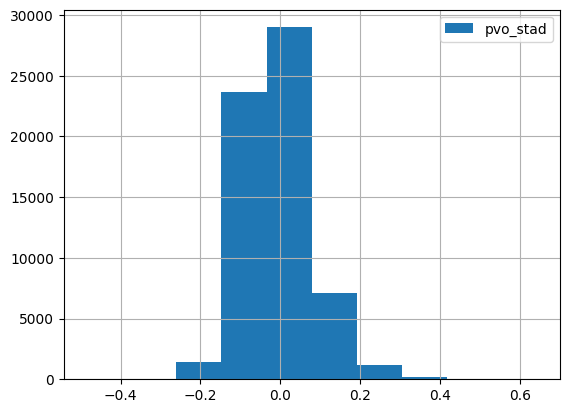

In [33]:
features['pvo_stad'].hist(legend = True)
print((features['pvo_stad'].abs() > 1).sum())

count    6.272500e+04
mean     2.039023e-18
std      9.998087e-01
min     -1.416296e+01
25%     -4.566884e-01
50%      1.354772e-02
75%      4.865267e-01
max      1.102990e+01
Name: log-ret_stad, dtype: float64


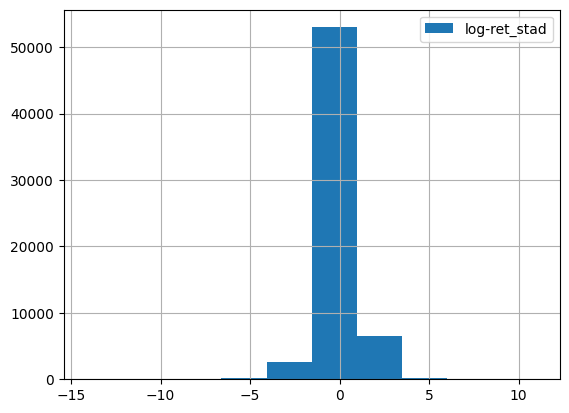

In [21]:
features['log-ret_stad'] = features.groupby('tic')['log-ret'].transform(standardize)
features['log-ret_stad'].hist(legend = True)
print(features['log-ret_stad'].describe())

In [37]:
features['adx_scale'] = features.groupby('tic')['adx'].transform(lambda x : (x - x.min()) / (x.max() - x.min()))
features['pdi_scale'] = features.groupby('tic')['pdi'].transform(lambda x : (x - x.min()) / (x.max() - x.min()))
features['ndi_scale'] = features.groupby('tic')['ndi'].transform(lambda x : (x - x.min()) / (x.max() - x.min()))
features.head()
features.reset_index(drop=True)

,date,open,high,low,close,volume,tic,log-ret,rsi_6,rsi,...,macd_stad,macds_stad,tema_stad,pvo_stad,adx_scale,log-ret_stad,pvos_stad,pvoh_stad,pdi_scale,ndi_scale
0,2016-01-27,27.603374,27.772948,26.827351,26.850345,642328247.0,Asset_001,-0.067965,6.520784,7.212268,...,-0.301518,-0.313021,-1.278697,0.027836,0.892053,-3.784435,0.014089,0.013747,0.000000,1.000000
1,2016-01-27,63.138625,63.369282,61.936796,62.179591,27033807.0,Asset_002,-0.018377,24.999527,27.082835,...,-0.308382,-0.327385,-1.283730,0.002332,0.908283,-1.148045,-0.000392,0.002724,0.000000,0.423291
2,2016-01-27,36.431252,36.664288,35.447055,35.732921,57710800.0,Asset_003,-0.018472,8.045363,8.883155,...,-0.315264,-0.322049,-1.132755,0.009031,1.000000,-1.070314,0.001856,0.007176,0.000000,0.578009
3,2016-01-27,34.438470,34.518561,33.110678,33.372117,74770606.0,Asset_004,-0.030223,18.015263,19.669184,...,-0.221556,-0.230316,-1.594366,0.005606,1.000000,-1.507732,0.001158,0.004448,0.000000,0.582442
4,2016-01-27,0.915523,0.918398,0.888690,0.905939,177477475.0,Asset_005,-0.011918,40.696758,43.332401,...,-0.283730,-0.299123,-0.695209,-0.004564,0.893964,-0.453288,-0.003137,-0.001427,0.000000,0.516429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62720,2026-01-16,232.642725,233.620270,231.553457,232.181878,10196870.0,Asset_021,0.000602,72.777809,67.604486,...,1.985544,1.441737,1.860982,0.067996,0.594821,0.008606,0.099003,-0.031007,0.692523,0.175104
62721,2026-01-16,61.607722,61.613287,60.333501,60.556073,12018443.0,Asset_022,-0.019473,49.981127,60.273501,...,2.460143,2.812208,1.659536,-0.037700,0.476680,-1.397353,-0.045251,0.007551,0.465768,0.156023
62722,2026-01-16,165.666938,167.003895,164.337672,164.698803,10923184.0,Asset_023,-0.003121,31.087846,39.121316,...,-1.404799,-0.876683,2.147955,0.087994,0.046079,-0.232095,0.058127,0.029867,0.314634,0.364893
62723,2026-01-16,1048.920905,1052.170140,1036.927007,1050.676360,3222702.0,Asset_024,0.007145,88.960738,74.592001,...,2.178596,0.761176,1.991266,0.019966,0.507633,0.457662,0.004161,0.015805,0.686078,0.175688


In [63]:
from pathlib import Path
panel_cols = [
    "date",
    "tic",
    "close",
    "volume",
    "rsi_6",
    "stochrsi_3",
    "volatility",
    "macd_stad",
    "macds_stad",
    "tema_stad",
    "pvo_stad",
    "pvos_stad",
    "pvoh_stad",
    "log-ret_stad",
    "adx_scale",
    "pdi_scale",
    "ndi_scale",
    "macd_signal",
    "rsi_signal",
    "adx_signal",
    "cci_signal",
    "macd_signal_held",
    "rsi_signal_held",
    "adx_signal_held",
    "cci_signal_held",
]
panel = features[panel_cols].dropna().sort_values(["date", "tic"])
out = Path("./data/features_panel.csv")
panel.to_csv(out, index=False)
print(out, panel.shape)

data/features_panel.csv (62725, 25)


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.decomposition import PCA

X = features.copy()
y = features['log-ret'].shift(-1)
X.drop(columns = ['date', 'tic','log-ret', 'open', 'high', 'low', 'volume', 'macd', 'macds','macdh', 'tema', 'pvo', 'pvoh', 'pvos', 'cci', 'rsi', 'pdi', 'ndi' ], inplace = True)
X.reset_index(drop=True)
print(X.columns)

mask = y.notna()
X, y = X[mask], y[mask]

tscv = TimeSeriesSplit(n_splits=5)

# 3. Cross-Validation Loop
fold = 1
for train_idx, val_idx in tscv.split(X):
    # Split data into Train and Validation for the current fold
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Scale features (PCA is highly sensitive to variance scales)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Apply PCA (Fit ONLY on training data to prevent future leakage)
    pca = PCA(n_components=3) 
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    
    # Initialize and train LightGBM Regressor
    model = lgb.LGBMRegressor(
        n_estimators=100, 
        learning_rate=0.05, 
        random_state=42,
        verbose=-1
    )
    model.fit(X_train_pca, y_train)
    
    # Predict and Evaluate
    predictions = model.predict(X_val_pca)
    rmse = np.sqrt(mse(y_val, predictions))
    
    print(f"Fold {fold} - Train Size: {len(train_idx)}, Val Size: {len(val_idx)}, RMSE: {rmse:.4f}")
    fold += 1



Index(['close', 'rsi_6', 'cci_6', 'dx', 'adx', 'adxr', 'close_5_sma',
       'close_20_ema', 'close_5_ema', 'cci_5', 'stochrsi_3', 'volatility',
       'macd_signal', 'rsi_signal', 'adx_signal', 'cci_signal',
       'macd_signal_held', 'rsi_signal_held', 'adx_signal_held',
       'cci_signal_held', 'macd_stad', 'macds_stad', 'tema_stad', 'pvo_stad',
       'adx_scale', 'log-ret_stad', 'pvos_stad', 'pvoh_stad', 'pdi_scale',
       'ndi_scale'],
      dtype='str')
Fold 1 - Train Size: 10454, Val Size: 10454, RMSE: 0.0168
Fold 2 - Train Size: 20908, Val Size: 10454, RMSE: 0.0239
Fold 3 - Train Size: 31362, Val Size: 10454, RMSE: 0.0196
Fold 4 - Train Size: 41816, Val Size: 10454, RMSE: 0.0181
Fold 5 - Train Size: 52270, Val Size: 10454, RMSE: 0.0202


count    10454.000000
mean         0.000709
std          0.020252
min         -0.253341
25%         -0.007800
50%          0.000913
75%          0.009757
max          0.218594
Name: log-ret, dtype: float64

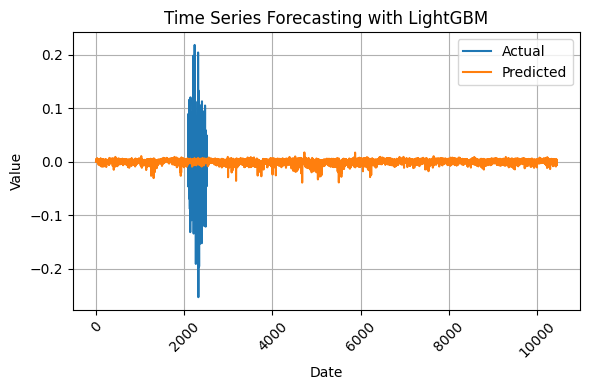

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(y_val, label='Actual')
plt.plot(predictions, label='Predicted')
plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Time Series Forecasting with LightGBM")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:
# Variation Inflation Factor : 
# VIF = 1 / (1 - R^2)